# Linear Regression for Branch Linear Entropy

## Description

Linear regression attempts to model the connection between two variables by fitting a linear equation to the observed data. 

Linear Branch Entropy paper uses least squreas which calculates the best fitting line for the observed data by minimizing the sum of the squares of the vertical deviations from each data point to the line.

If the point lies exactly on the regression line, then it’s vertical deviations is 0. The deviations are first squared and summed, so there is no risk of cancellations between the predicted points up or down the regression line. This concept is also used in loss function in linear regression (Mean Square Error).

Linear regression models the relationship between two variables by fitting a linear function to the observed data.

Linear Branch Entropy (LBE) uses least-squares linear regression to model the relationship between branch entropy and branch miss rate. Least squares determines the best-fitting line by minimizing the squared differences between the observed and predicted branch miss rates.

In this notebook, the least-squares linear regression is performed by minimizing the Mean Squared Error (MSE) using the Adam optimizaer. The resulting model is expressed as:

$$
\mathrm{Miss}(e) = \beta e + \alpha
$$

where $e$ is the branch entropy, $\beta$ is the slope, and $\alpha$ is the intercept.

### Step 1-1: Required Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

### Step 1-2: Loading and Preparing the Training Dataset

In [2]:
train_data = np.loadtxt(
    "../dataset/lbe/tagescl_train.csv",
    delimiter=",",
    skiprows=1,
    ndmin=2
)

if train_data.shape[1] != 2:
    raise ValueError(
        "Input CSV must contain exactly two columns: "
        "branch_entropy and branch_miss_rate."
    )

if not np.isfinite(train_data).all():
    raise ValueError("Input CSV contains NaN or infinite values.")

x_input = torch.tensor(
    train_data[:, 0],
    dtype=torch.double
)

y_input = torch.tensor(
    train_data[:, 1],
    dtype=torch.double
)

print("Number of entropy values = ",x_input.shape) 
print("Number of branch miss rate =", y_input.shape)


Number of entropy values =  torch.Size([35])
Number of branch miss rate = torch.Size([35])


### Step 2: Building and Configuring the Linear Model

In [3]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.a = torch.nn.Parameter(torch.randn(1, dtype=torch.double))
        self.b = torch.nn.Parameter(torch.randn(1, dtype=torch.double))

    def forward(self, x):
        return self.a * x + self.b

model = LinearModel()

criterion = torch.nn.MSELoss()

learning_rate = 0.01
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr = learning_rate
)

### Step 3: Training the Linear Model

In [4]:
num_epochs = 30000

loss_history = []

for epoch in range(1, num_epochs + 1):

    optimizer.zero_grad()

    y_pred = model(x_input)

    loss=criterion(y_input, y_pred)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % (num_epochs // 10) == 0:
        print(f"Epoch {epoch}: loss = {loss.item()}")

# Deriving model parameters
beta = model.a.item()  # beta (slope)
alpha = model.b.item()  # alpha (intercept)

print(f"Derived Alpha: {alpha}")
print(f"Derived Beta: {beta}")

Epoch 3000: loss = 17.943604662378796
Epoch 6000: loss = 16.931548507459805
Epoch 9000: loss = 16.032901415348224
Epoch 12000: loss = 15.2683548046107
Epoch 15000: loss = 14.637451056049395
Epoch 18000: loss = 14.138267388529936
Epoch 21000: loss = 13.76785663323669
Epoch 24000: loss = 13.521299382205392
Epoch 27000: loss = 13.389066254310794
Epoch 30000: loss = 13.34827065109054
Derived Alpha: 2.646914298980329
Derived Beta: 258.8417244743083


### Step 4: Visualizing the Fitted Model and Training Loss

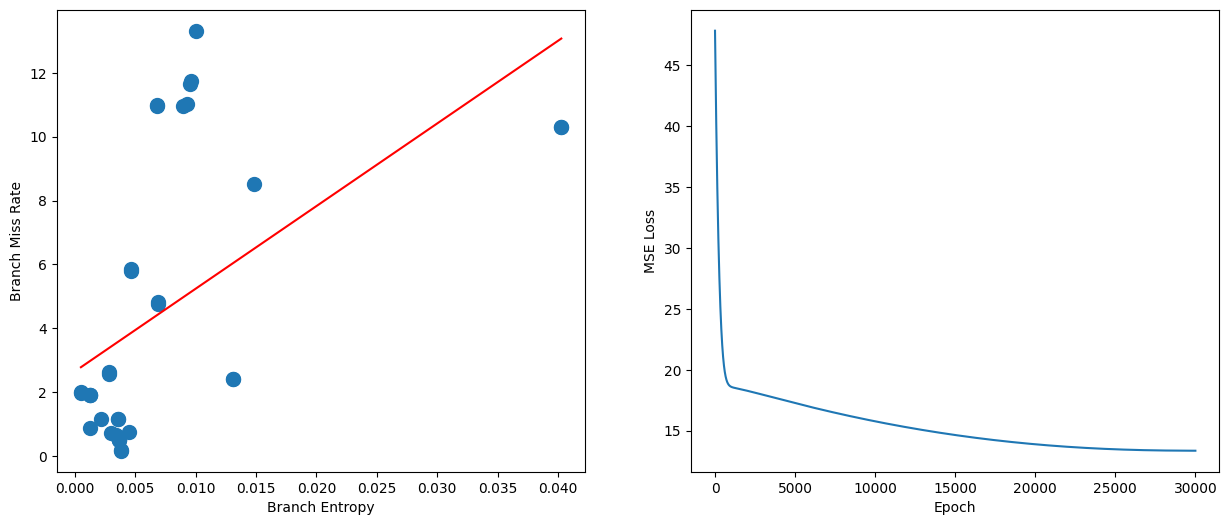

In [5]:
def visualize(x_input, y_input, loss_history, model, marker_size = 1):

    x_input = x_input.numpy()
    y_input = y_input.numpy()

    plt.figure(figsize=(15, 6))

    # Data points and fitted linear model
    plt.subplot(121)

    plt.scatter(x_input, y_input, s = marker_size) 

    x = np.linspace(x_input.min(), x_input.max(), 100)

    with torch.no_grad():
        y = model(
            torch.tensor(x, dtype=torch.double)
        ).numpy()
    
    plt.plot(x, y, c="red")

    plt.xlabel("Branch Entropy")
    plt.ylabel("Branch Miss Rate")

    # Second figure: training loss
    plt.subplot(122)

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.plot(loss_history)

    plt.show()

visualize(x_input, y_input, loss_history, model, marker_size = 100)